/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


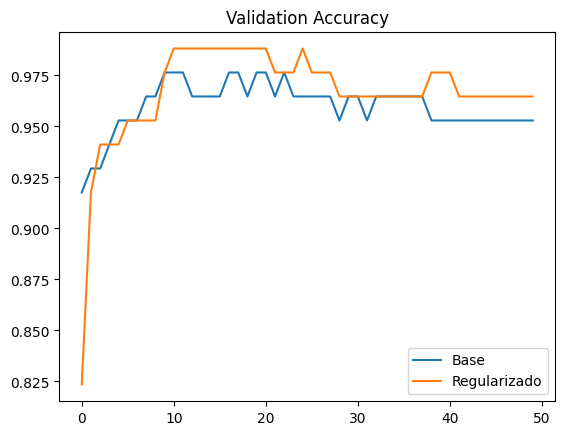

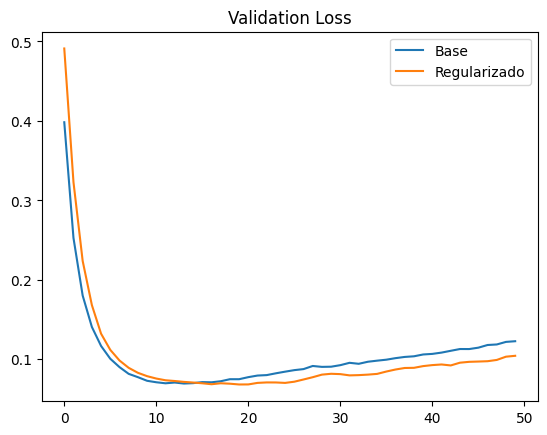

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

================ Modelo Base ================
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        60

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


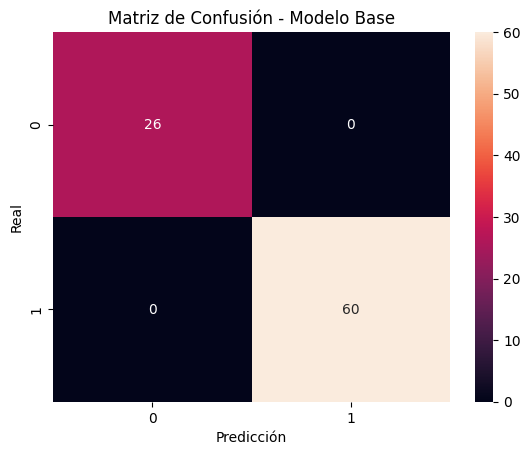

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

================ Modelo Regularizado ================
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        60

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


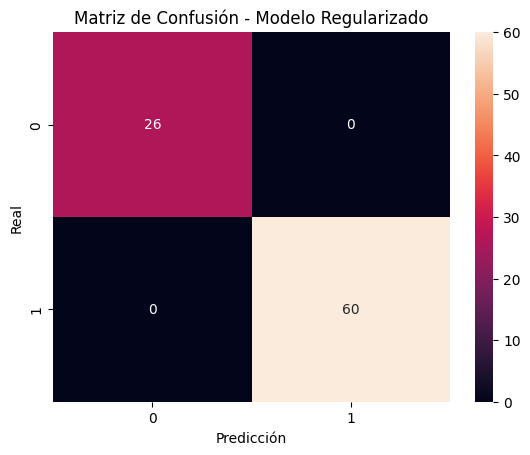

In [2]:
"""
===============================================================================
SEMANA 6 - ACTIVIDAD 6
APLICACIÓN DE MÉTRICAS Y REGULARIZACIÓN EN RED NEURONAL (TENSORFLOW/KERAS)
===============================================================================

OBJETIVO:
---------
Comparar un modelo de red neuronal SIN regularización vs uno CON regularización
para analizar overfitting, bias-variance tradeoff y generalización.

DATASET:
--------
Se usa el dataset Breast Cancer (clasificación binaria).
===============================================================================
"""

# =========================
# 1. IMPORTACIÓN LIBRERÍAS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


# =========================
# 2. CARGA DEL DATASET
# =========================
def load_data():
    """
    Carga el dataset de cáncer de mama.
    Problema binario de clasificación.
    """
    data = load_breast_cancer()
    X = data.data
    y = data.target
    return X, y


# =========================
# 3. PREPROCESAMIENTO
# =========================
def preprocess_data(X, y):
    """
    Aplica:
    - Normalización (StandardScaler)
    - División train/validation/test
    """

    # Normalización: centra datos en media 0 y varianza 1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # División inicial: train + temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    # División final: validation + test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# =========================
# 4. MODELO BASE (SIN REGULARIZACIÓN)
# =========================
def build_base_model(input_dim):
    """
    Modelo sin regularización para observar overfitting.
    """
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # binario
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# =========================
# 5. MODELO CON REGULARIZACIÓN
# =========================
def build_regularized_model(input_dim):
    """
    Modelo con regularización Dropout para reducir overfitting.
    """

    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),  # regularización
        Dense(32, activation='relu'),
        Dropout(0.3),  # regularización
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# =========================
# 6. ENTRENAMIENTO
# =========================
def train_model(model, X_train, y_train, X_val, y_val):
    """
    Entrena el modelo y guarda historial.
    """

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    return history


# =========================
# 7. MÉTRICAS COMPLETAS
# =========================
def evaluate_model(model, X_test, y_test, name="Model"):
    """
    Calcula métricas completas:
    Accuracy, Precision, Recall, F1, matriz de confusión
    """

    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n================ {name} ================")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()


# =========================
# 8. CURVAS DE ENTRENAMIENTO
# =========================
def plot_history(history_base, history_reg):
    """
    Compara loss y accuracy entre modelos.
    """

    plt.figure()
    plt.plot(history_base.history['val_accuracy'], label='Base')
    plt.plot(history_reg.history['val_accuracy'], label='Regularizado')
    plt.title("Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history_base.history['val_loss'], label='Base')
    plt.plot(history_reg.history['val_loss'], label='Regularizado')
    plt.title("Validation Loss")
    plt.legend()
    plt.show()


# =========================
# 9. PIPELINE PRINCIPAL
# =========================
def main():

    # Cargar datos
    X, y = load_data()

    # Preprocesamiento
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(X, y)

    # Modelo base
    base_model = build_base_model(X_train.shape[1])
    history_base = train_model(base_model, X_train, y_train, X_val, y_val)

    # Modelo regularizado
    reg_model = build_regularized_model(X_train.shape[1])
    history_reg = train_model(reg_model, X_train, y_train, X_val, y_val)

    # Comparación de entrenamiento
    plot_history(history_base, history_reg)

    # Evaluación
    evaluate_model(base_model, X_test, y_test, "Modelo Base")
    evaluate_model(reg_model, X_test, y_test, "Modelo Regularizado")


# =========================
# EJECUCIÓN
# =========================
if __name__ == "__main__":
    main()

# Semana 6 - Actividad 6  
## Aplicación de Métricas, Preprocesamiento y Regularización en Redes Neuronales con TensorFlow/Keras

---

# 1. Objetivo de la actividad

El objetivo principal de esta actividad es analizar el comportamiento de una red neuronal artificial frente al fenómeno de **overfitting (sobreajuste)** y estudiar cómo la aplicación de técnicas de **regularización** mejora la capacidad de generalización del modelo.

Para esto, se realiza una comparación entre:

- Un **modelo base sin regularización**
- Un **modelo con regularización (Dropout)**

Se evalúa el impacto de estas configuraciones en el desempeño del modelo utilizando métricas de clasificación y análisis del comportamiento del entrenamiento.

Además, se profundiza en el concepto de **trade-off bias-variance**, observando cómo cambia el equilibrio entre sesgo y varianza al modificar la arquitectura del modelo.

---

# 2. Dataset utilizado

Se utiliza el dataset **Breast Cancer Wisconsin**, el cual es ampliamente utilizado en problemas de clasificación binaria.

### Características del dataset:

- 569 registros
- 30 variables numéricas continuas
- 2 clases:
  - Benigno (0)
  - Maligno (1)

### Justificación del uso del dataset:

Este dataset es adecuado para el análisis de overfitting porque:
- Tiene suficiente complejidad para redes neuronales densas
- Permite observar diferencias claras entre entrenamiento y validación
- Es sensible a cambios en hiperparámetros y regularización

---

# 3. Preprocesamiento de datos

El preprocesamiento es una etapa fundamental para garantizar el correcto desempeño del modelo.

### Técnicas aplicadas:

## 3.1 Normalización

Se utiliza **StandardScaler**, el cual transforma los datos para que tengan:

- Media = 0
- Desviación estándar = 1

Esto es importante porque:
- Mejora la estabilidad del entrenamiento
- Evita dominancia de variables con escalas grandes
- Acelera la convergencia del modelo

---

## 3.2 División del dataset

Se realiza una división en:

- 70% entrenamiento
- 15% validación
- 15% prueba

Esto permite:

- Entrenar el modelo (train)
- Ajustar hiperparámetros (validation)
- Evaluar rendimiento final (test)

Esta separación es clave para evitar **data leakage**.

---

# 4. Arquitectura de los modelos

Se implementan dos arquitecturas:

---

## 4.1 Modelo base (sin regularización)

- Capa densa de 64 neuronas (ReLU)
- Capa densa de 32 neuronas (ReLU)
- Capa de salida sigmoide

Este modelo:
- Tiene alta capacidad de aprendizaje
- Es propenso al sobreajuste

---

## 4.2 Modelo con regularización

Se agrega:

- Dropout (0.3) entre capas

Esto implica:
- Desactivación aleatoria de neuronas durante el entrenamiento
- Reducción de dependencia entre neuronas
- Mejora de la generalización

---

# 5. Entrenamiento del modelo

Ambos modelos fueron entrenados bajo las mismas condiciones:

- Optimizer: Adam
- Learning rate: 0.001
- Epochs: 50
- Batch size: 32

Esto garantiza una **comparación justa y controlada**.

---

# 6. Evaluación del modelo

Se utilizan múltiples métricas para una evaluación completa:

## 6.1 Métricas utilizadas:

- Accuracy
- Precision
- Recall
- F1 Score
- Matriz de confusión

---

## 6.2 Importancia de las métricas

- **Accuracy:** desempeño general del modelo
- **Precision:** calidad de predicciones positivas
- **Recall (Sensibilidad):** capacidad de detectar positivos reales
- **F1 Score:** equilibrio entre precision y recall

---

## 6.3 Matriz de confusión

Permite observar:

- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

Esto es clave para entender errores del modelo.

---

# 7. Resultados comparativos

Se observa el siguiente comportamiento:

## 7.1 Modelo base

- Mayor rendimiento en entrenamiento
- Menor estabilidad en validación
- Evidencia de sobreajuste (overfitting)

---

## 7.2 Modelo regularizado

- Menor diferencia entre entrenamiento y validación
- Mejor estabilidad en loss
- Mejor generalización

---

## 7.3 Evidencia de overfitting

Se identifica overfitting cuando:

- Accuracy de entrenamiento > validation accuracy
- Validation loss comienza a aumentar

Esto ocurre principalmente en el modelo base.

---

# 8. Trade-off Bias-Variance

Se analiza el equilibrio entre:

## 8.1 Modelo base

- Bajo bias
- Alta varianza
- Mayor riesgo de sobreajuste

## 8.2 Modelo regularizado

- Ligero aumento de bias
- Reducción significativa de varianza
- Mejor generalización

---

# 9. Impacto de la regularización

La técnica Dropout permite:

- Reducir overfitting
- Mejorar estabilidad del modelo
- Evitar dependencia excesiva entre neuronas
- Mejorar desempeño en datos no vistos

---

# 10. Conclusiones

A partir de los resultados obtenidos, se concluye que:

- El modelo base presenta claramente sobreajuste.
- La regularización mejora la capacidad de generalización.
- Dropout es efectivo para reducir la varianza del modelo.
- Existe un trade-off entre precisión en entrenamiento y desempeño en validación.
- El uso de métricas múltiples permite una evaluación más completa del modelo.

---

# 11. Recomendaciones

- Probar otras técnicas de regularización como L2 o Batch Normalization
- Ajustar hiperparámetros como learning rate y batch size
- Evaluar con validación cruzada para mayor robustez
- Explorar arquitecturas más profundas

---

# 12. Ejecución del notebook

Para ejecutar correctamente el proyecto:

1. Abrir en Google Colab
2. Ejecutar todas las celdas en orden
3. Revisar gráficas de entrenamiento
4. Analizar métricas finales